In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import gwosc
import gwpy.table
from pesummary.io import read

import cogwheel.gw_plotting
from cogwheel import data
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import get_event_data, add_derived_quantities, load_posterior_samples, load_lvk_samples

In [3]:
# which event do we want to check out?
eventname = 'GW241011_233834'
catalog = 'O4_Discovery_Papers'

In [4]:
# get the event data
# output_dir = Path(os.path.join('/home/javier.roulet/cogwheel-catalog/processed_data', catalog, eventname))
# event_data = data.EventData.from_npz(filename=output_dir/f'{eventname}.npz')
event_data = get_event_data(eventname)

Skipping existing file /home/abbye.williams/cogwheel/cogwheel/data/gwosc_files/GW241011_233834/H_GW241011_233834.hdf5
Skipping existing file /home/abbye.williams/cogwheel/cogwheel/data/gwosc_files/GW241011_233834/V_GW241011_233834.hdf5


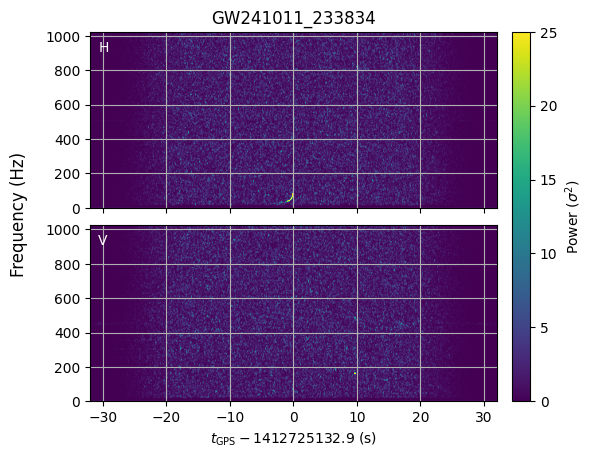

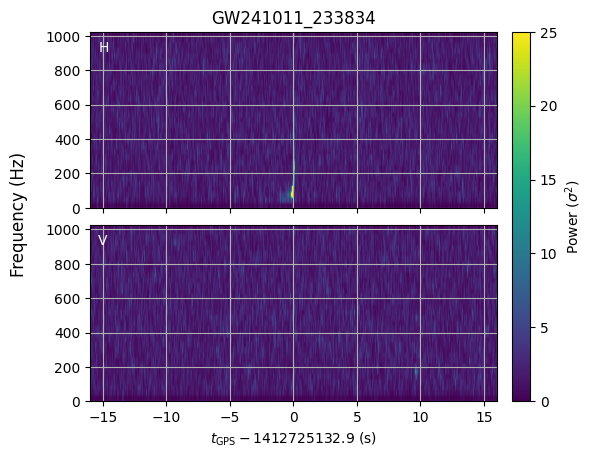

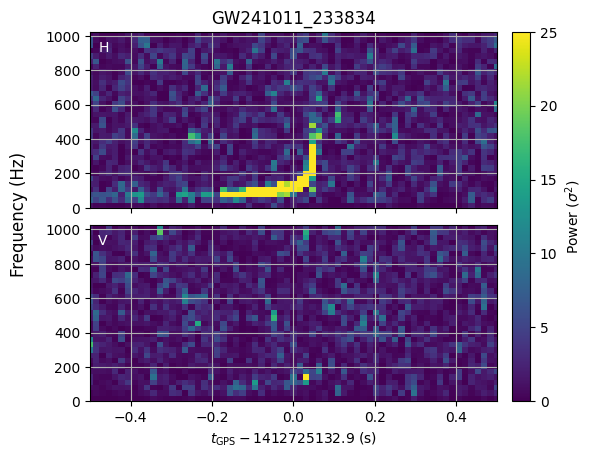

In [5]:
# check out the spectrogram
event_data.specgram(nfft=512)
kwargs = dict(
    fmax = 1024,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

In [6]:
# load our posterior samples and the released samples from the LVK PE
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples = load_posterior_samples(eventname, event_path)
# samples_lvk = load_lvk_samples(eventname, catalog=catalog)

loaded posterior samples for GW241011_233834 run 0


In [7]:
plot_params = [
    'mchirp',
    'lnq',
    'iota',
    'phi_ref',
    'psi',
    'd_luminosity',
    'p_lensed'
]

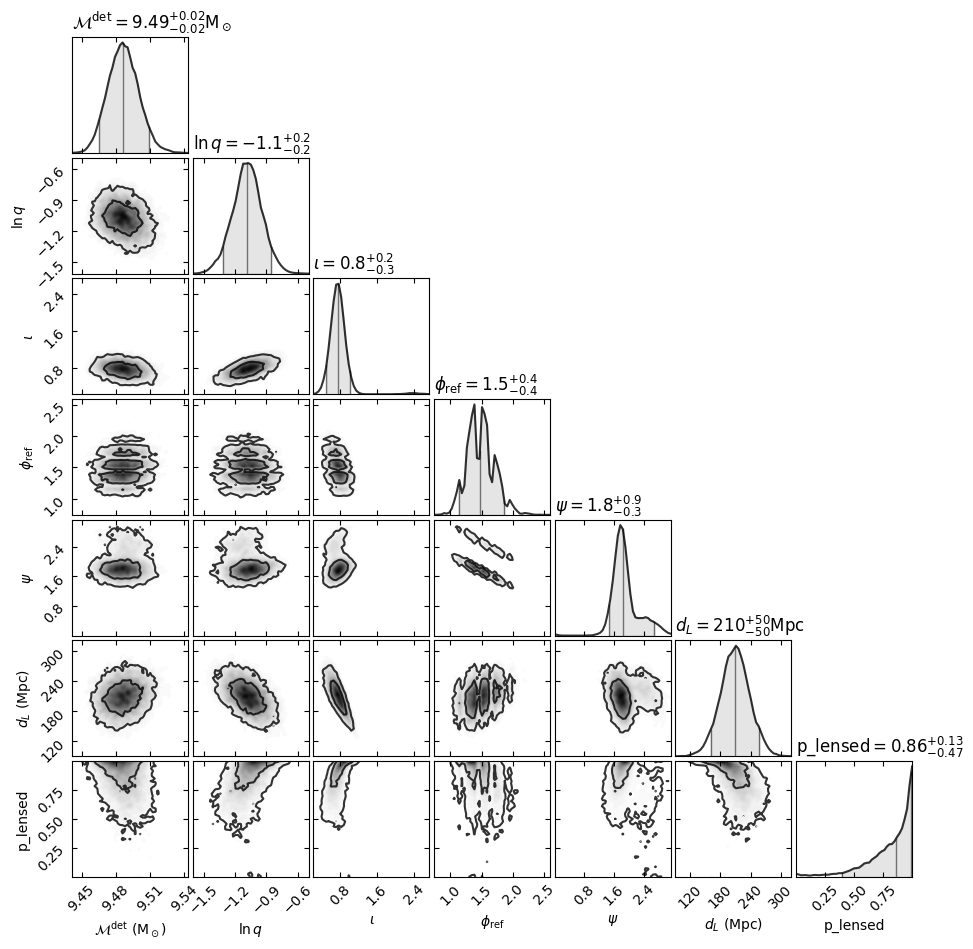

In [8]:
corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d='k',
        kwargs_1d=dict(color='k', alpha=0.8), contour_kwargs=dict(alpha=0.8)
)
corner_plot.plot()

In [11]:
# compute Bayes factor and uncertainty
n_resamples = 1000
bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
# log these
lnbayes_factors = np.log(bayes_factors)
# get the median and standard deviation
lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
print(lnbayes, lnbayes_std)

1.3744214217882194 0.011217956702053654


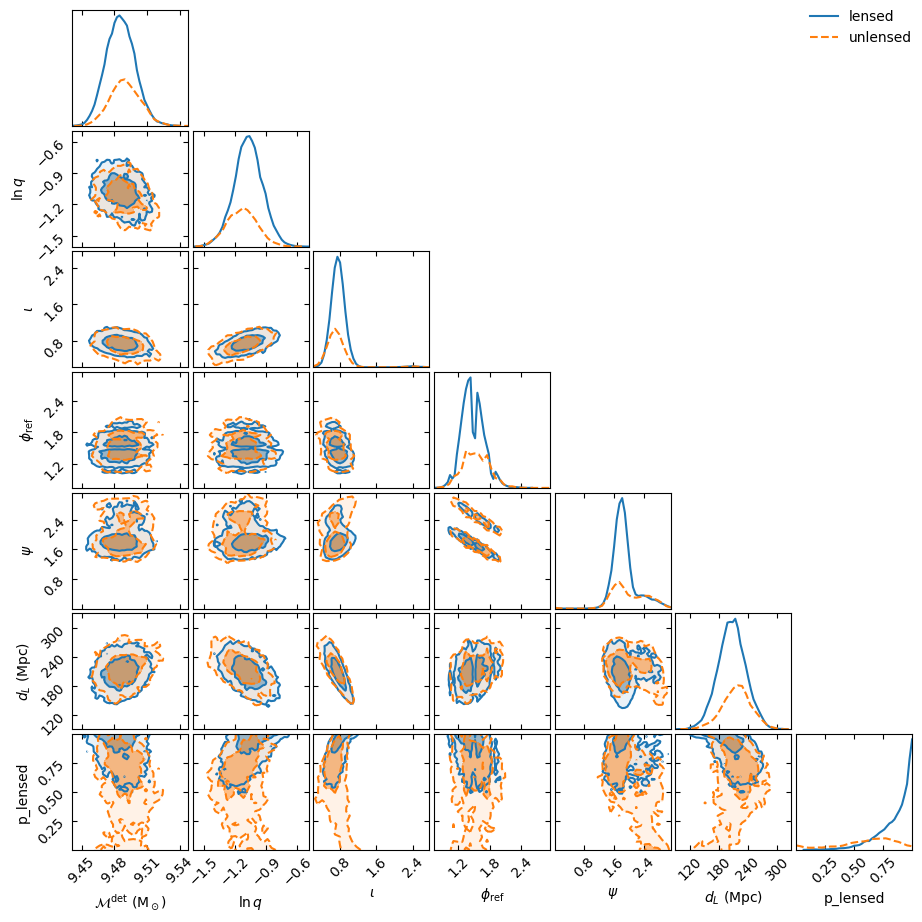

In [10]:
# posterior assuming everything is lensed
lensed = np.random.uniform(size=len(samples)) < samples['p_lensed']

corner_plot = cogwheel.gw_plotting.MultiCornerPlot(
        {'lensed' : samples[lensed], 'unlensed' : samples[~lensed]}, params=plot_params, tail_probability=1e-4, density=False
)
corner_plot.plot()